In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import numpy as np
import os

# Nature-style font settings (same as LLM1/figure_final.ipynb)
mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'figure.dpi': 300,
})

disease_list = ['ADs', 'AKI', 'FH', 'MACE', 'T2DM']
reviewers = ['AA', 'BB']

llm_colors = {'o3': '#5FB49C', 'opus': '#D2654A'}
llm_labels = {'o3': 'OpenAI o3', 'opus': 'Claude Opus 4.1'}




In [4]:
def load_overall(folder):
    """Load all 5 diseases x 2 reviewers from folder, average across both,
    then average across diseases. Returns DataFrame indexed by ['ALL','TEXT','DIAG']."""
    disease_dfs = []
    for disease in disease_list:
        reviewer_dfs = [
            pd.read_csv(f'{folder}/{disease}_{r} copy.csv').set_index('Setting')
            for r in reviewers
        ]
        disease_mean = (reviewer_dfs[0] + reviewer_dfs[1]) / 2
        disease_dfs.append(disease_mean)
    overall = sum(disease_dfs) / len(disease_list)
    return overall

overall_data_llm1 = load_overall('LLM1')
overall_data_llm2 = load_overall('LLM2')

print('LLM1 overall (OpenAI o3):')
print(overall_data_llm1.round(2))
print()
print('LLM2 overall (Claude Opus 4.1):')
print(overall_data_llm2.round(2))

LLM1 overall (OpenAI o3):
         Logical & Boolean accuracy  Temporal constraint implementation  \
Setting                                                                   
ALL                             3.3                                 3.3   
TEXT                            3.2                                 3.0   
DIAG                            1.3                                 1.0   

         Value-Set precision  OMOP schema  Coding efficiency  \
Setting                                                        
ALL                      2.7          2.6                2.7   
TEXT                     2.7          2.6                2.7   
DIAG                     1.0          2.3                2.0   

         Human readability  Revision effort  
Setting                                      
ALL                    3.6              2.4  
TEXT                   3.5              2.0  
DIAG                   2.8              0.4  

LLM2 overall (Claude Opus 4.1):
         Logic

In [5]:
def draw_comparison_radar(setting, title, save_path):
    """Draw a radar plot comparing LLM1 (o3) vs LLM2 (opus) for one setting row."""
    row1 = overall_data_llm1.loc[setting]
    row2 = overall_data_llm2.loc[setting]

    categories = list(overall_data_llm1.columns)
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the loop

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for key, row in [('o3', row1), ('opus', row2)]:
        values = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, values, label=llm_labels[key],
                linewidth=2.5, color=llm_colors[key])
        ax.fill(angles, values, alpha=0.15, color=llm_colors[key])

    # Axis labels with alignment per quadrant
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=13)
    for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
        angle_deg = np.degrees(angle)
        if 90 < angle_deg <= 270:
            label.set_horizontalalignment('right')
        else:
            label.set_horizontalalignment('left')

    ax.set_rlabel_position(22.5)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(['1', '2', '3', '4'], color='grey', size=11)
    ax.set_ylim(0, 4)

    # Minimal grid style (Nature)
    ax.spines['polar'].set_visible(False)
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

    ax.set_title(title, size=16, fontweight='bold', pad=20)
    # No legend embedded — saved separately as fig_comparison/legend.png

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', format='png')
    plt.show()
    print(f'Saved: {save_path}')

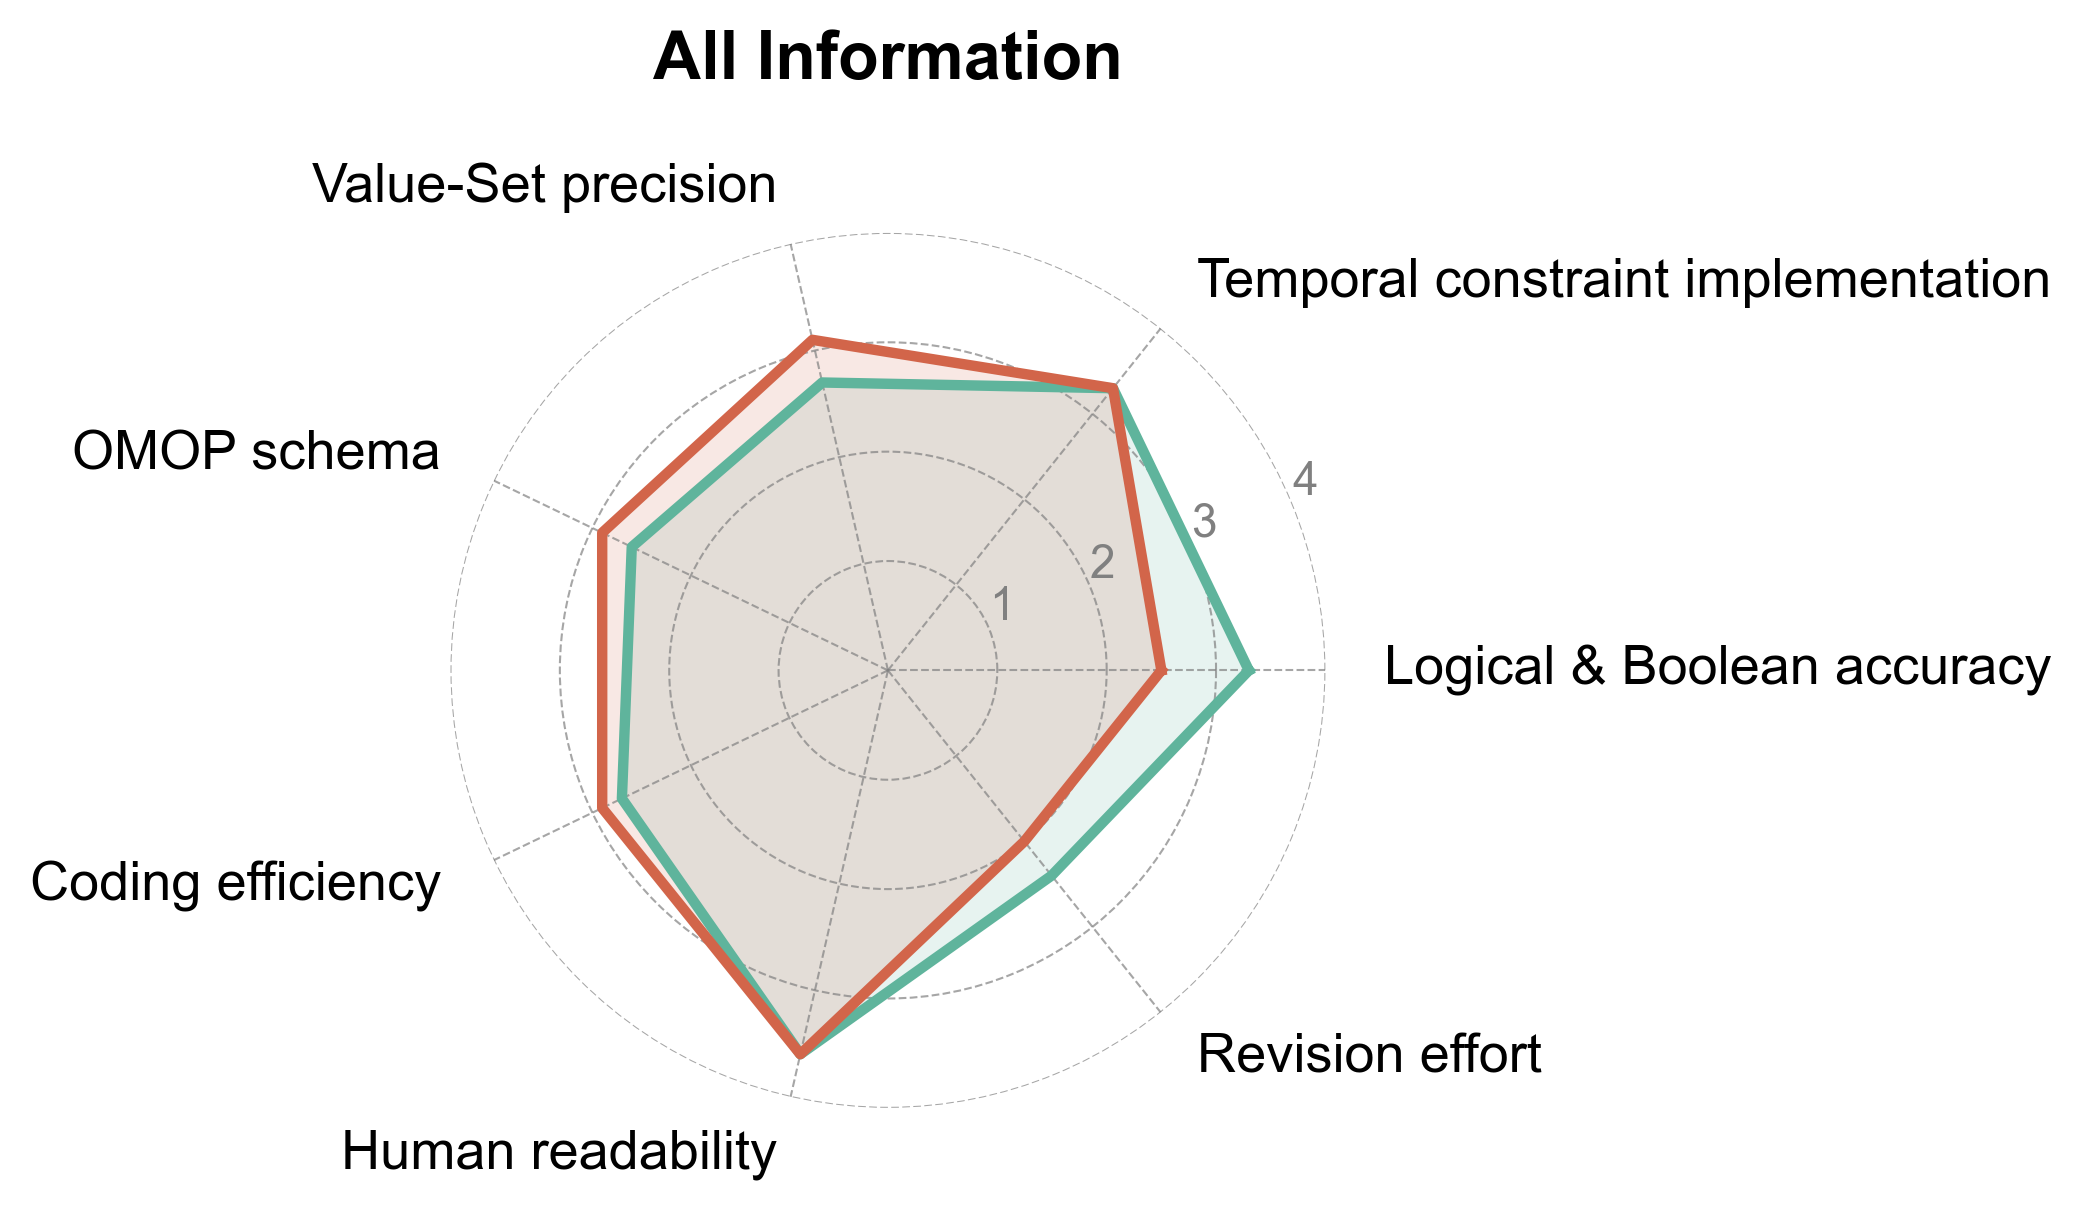

Saved: fig_comparison/radar_ALL.png


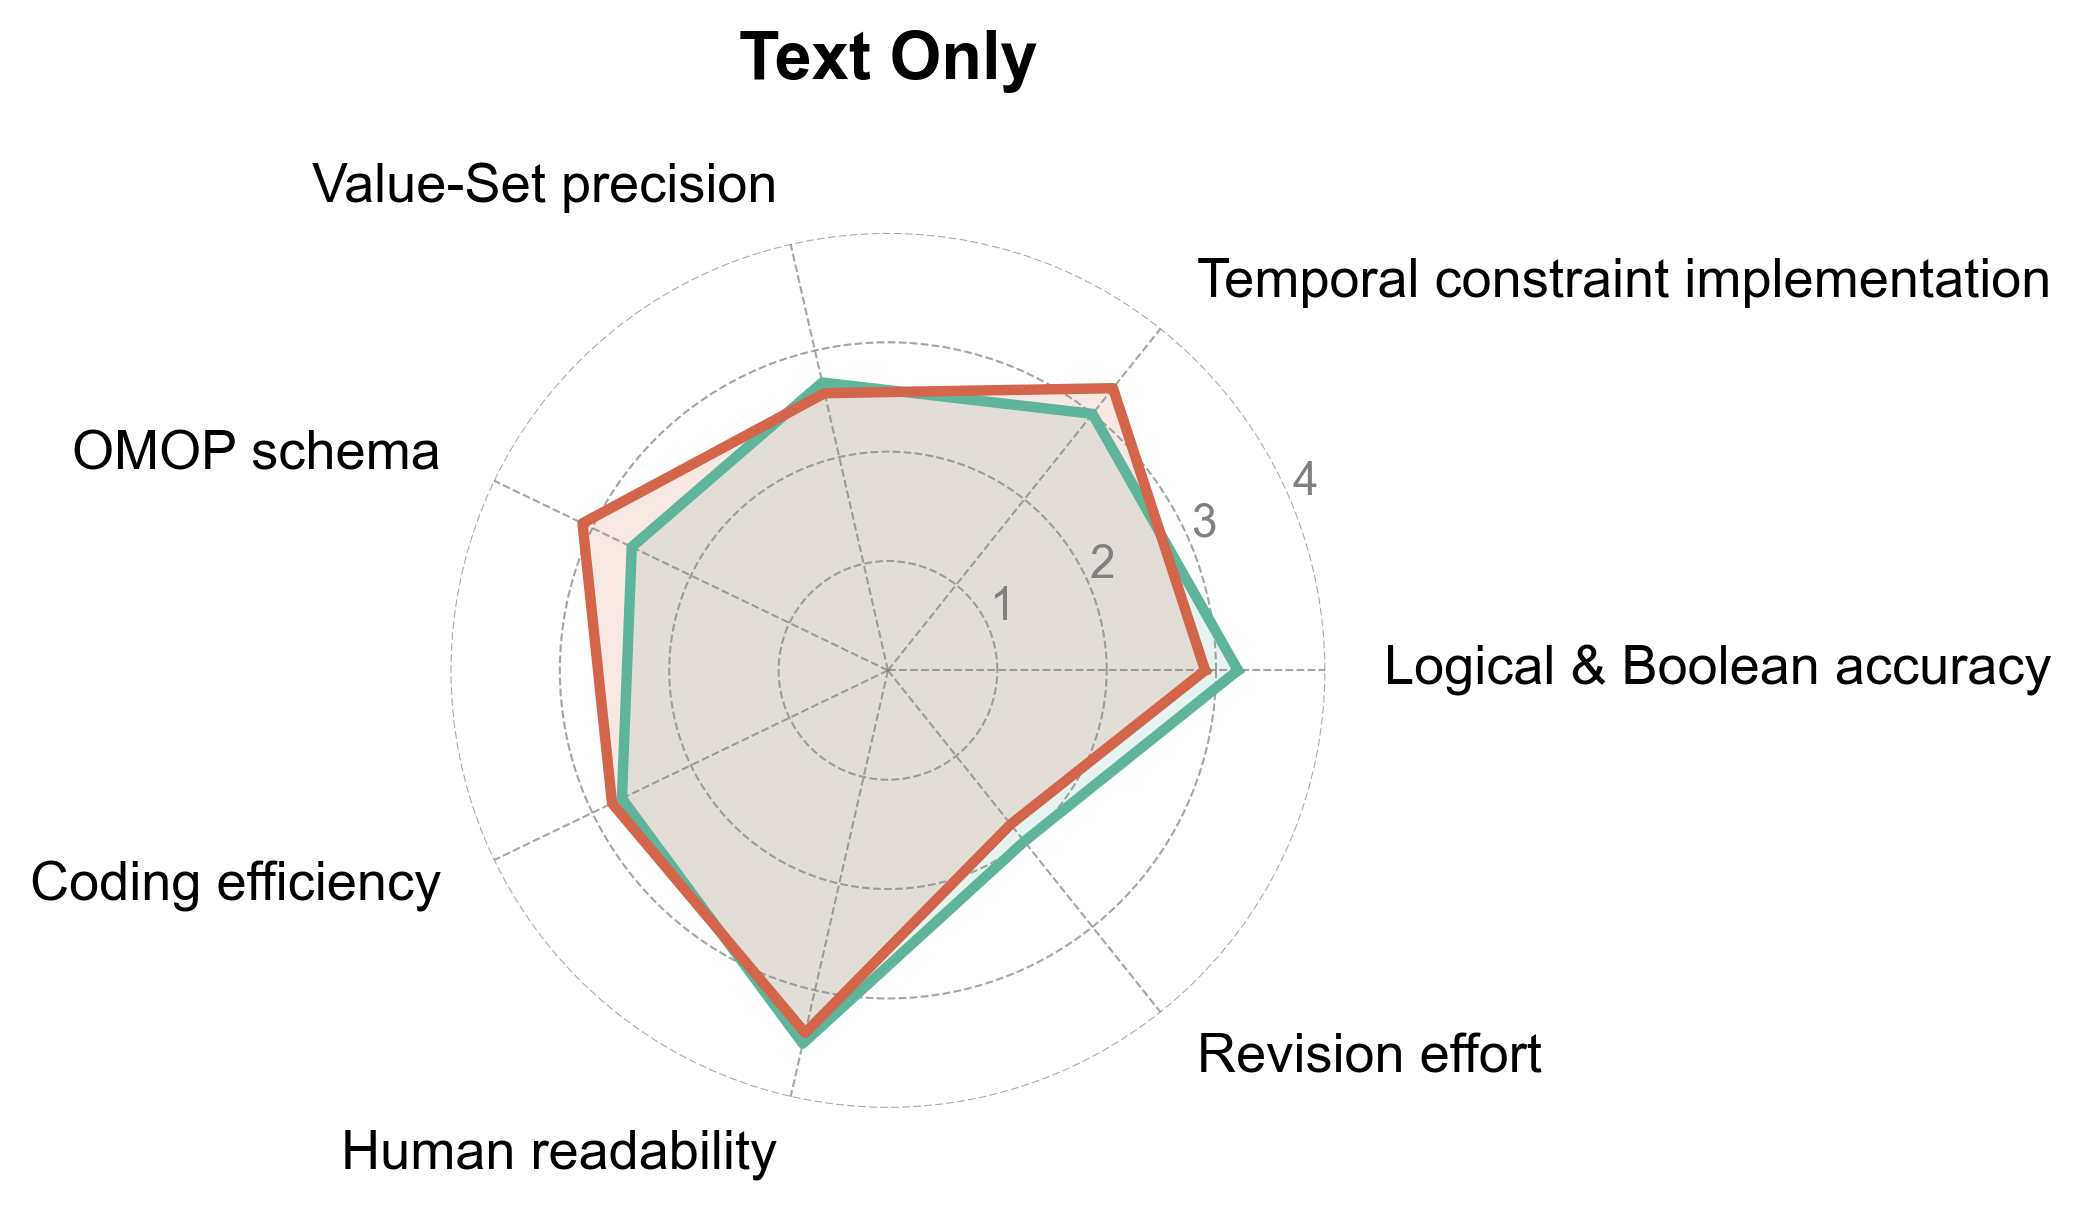

Saved: fig_comparison/radar_TEXT.png


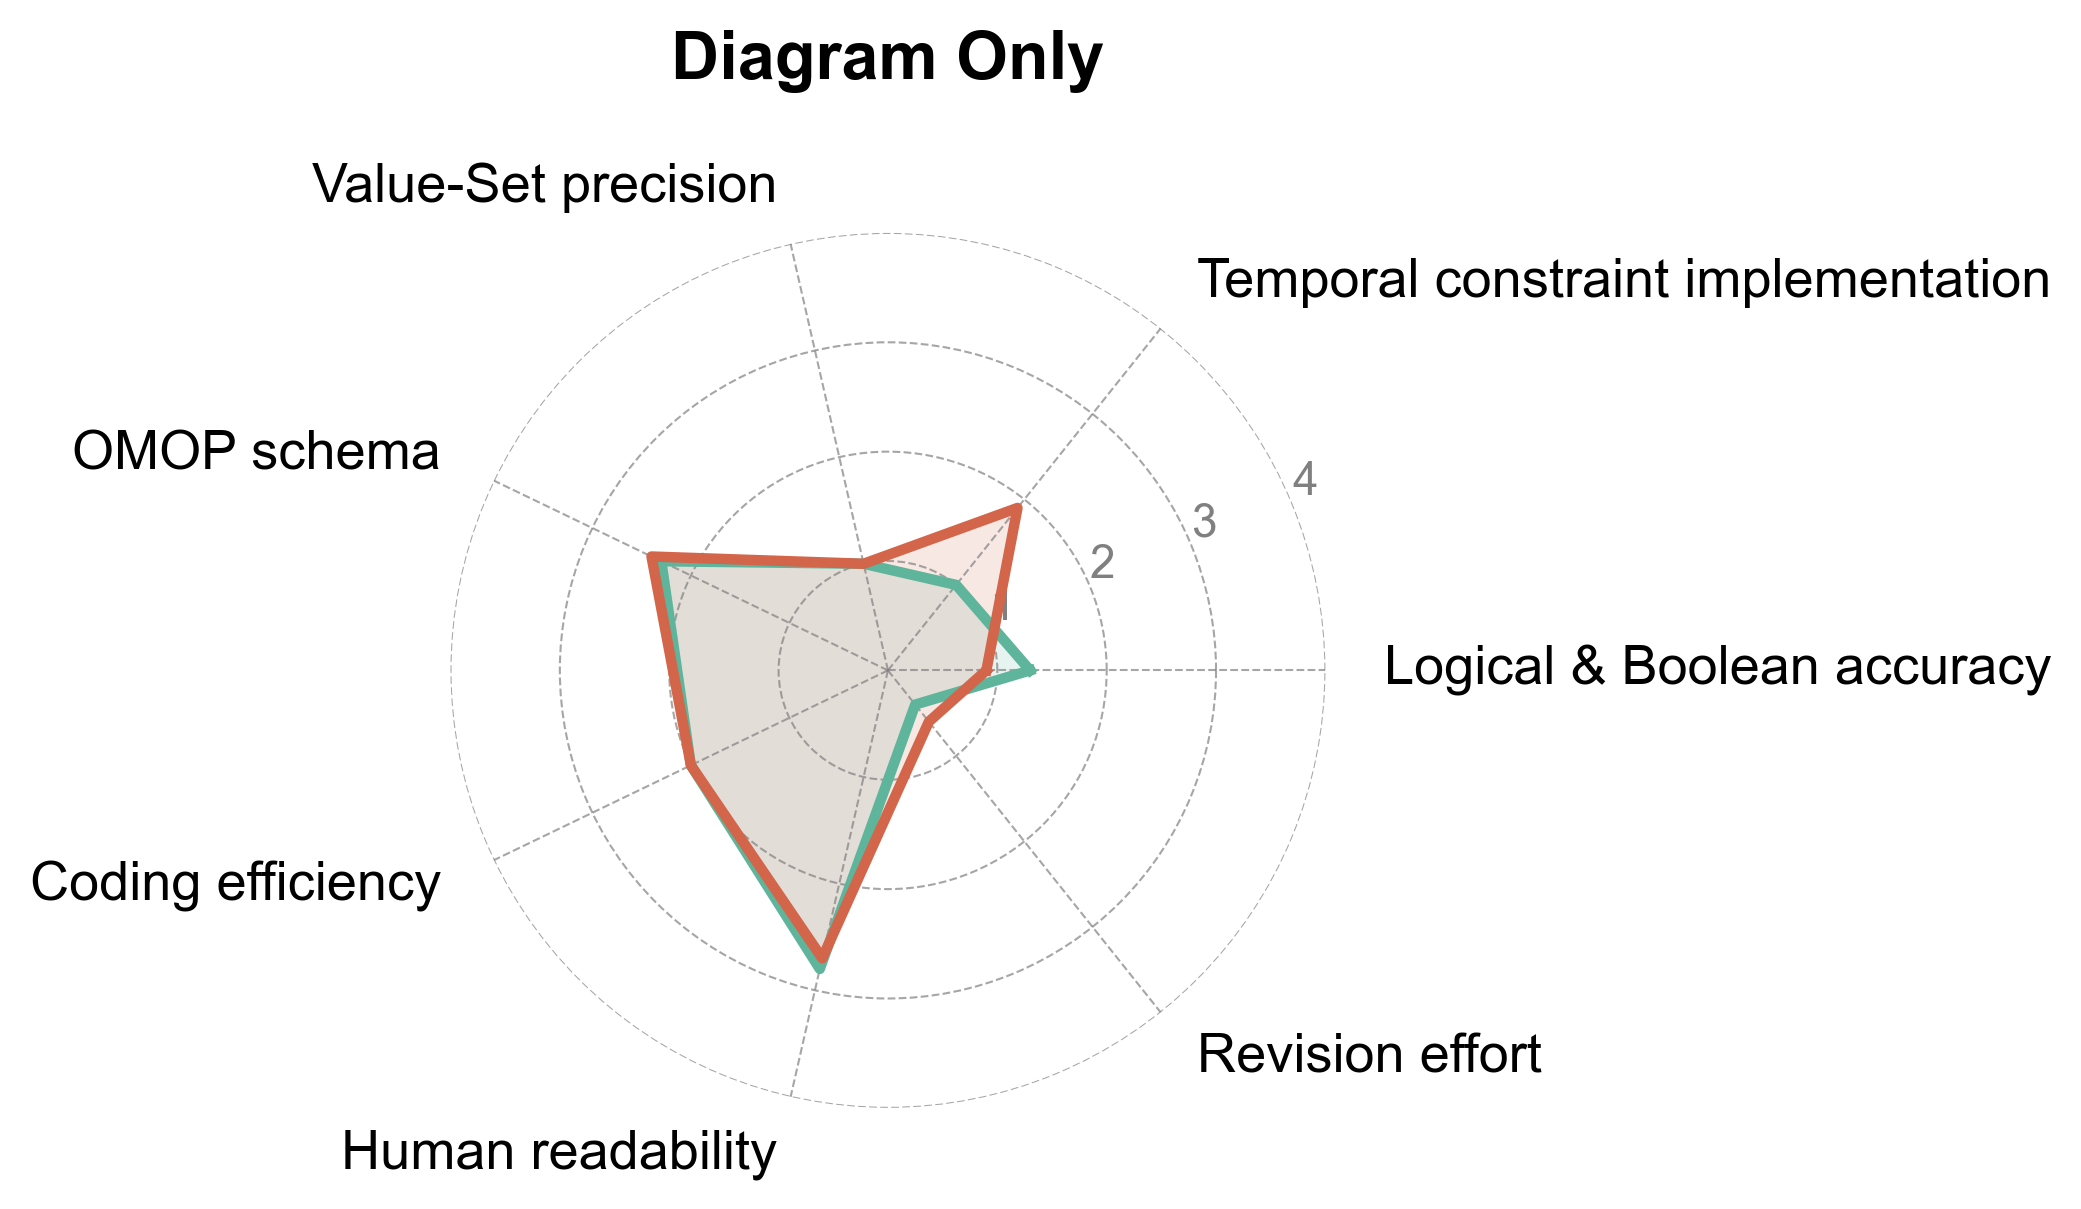

Saved: fig_comparison/radar_DIAG.png


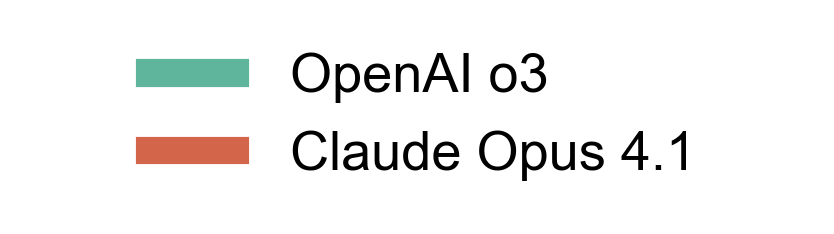

Saved: fig_comparison/legend.png


In [6]:
os.makedirs('fig_comparison', exist_ok=True)

draw_comparison_radar('ALL',  'All Information',  'fig_comparison/radar_ALL.png')
draw_comparison_radar('TEXT', 'Text Only',        'fig_comparison/radar_TEXT.png')
draw_comparison_radar('DIAG', 'Diagram Only',     'fig_comparison/radar_DIAG.png')

# Standalone legend
fig_leg, ax_leg = plt.subplots(figsize=(3, 1.0))
ax_leg.axis('off')
handles = [
    mpatches.Patch(color=llm_colors['o3'],   label=llm_labels['o3']),
    mpatches.Patch(color=llm_colors['opus'], label=llm_labels['opus']),
]
ax_leg.legend(handles=handles, loc='center', frameon=False, fontsize=13, ncol=1, handleheight=0.3)
plt.tight_layout()
plt.savefig('fig_comparison/legend.png', dpi=300, bbox_inches='tight', format='png')
plt.show()
print('Saved: fig_comparison/legend.png')

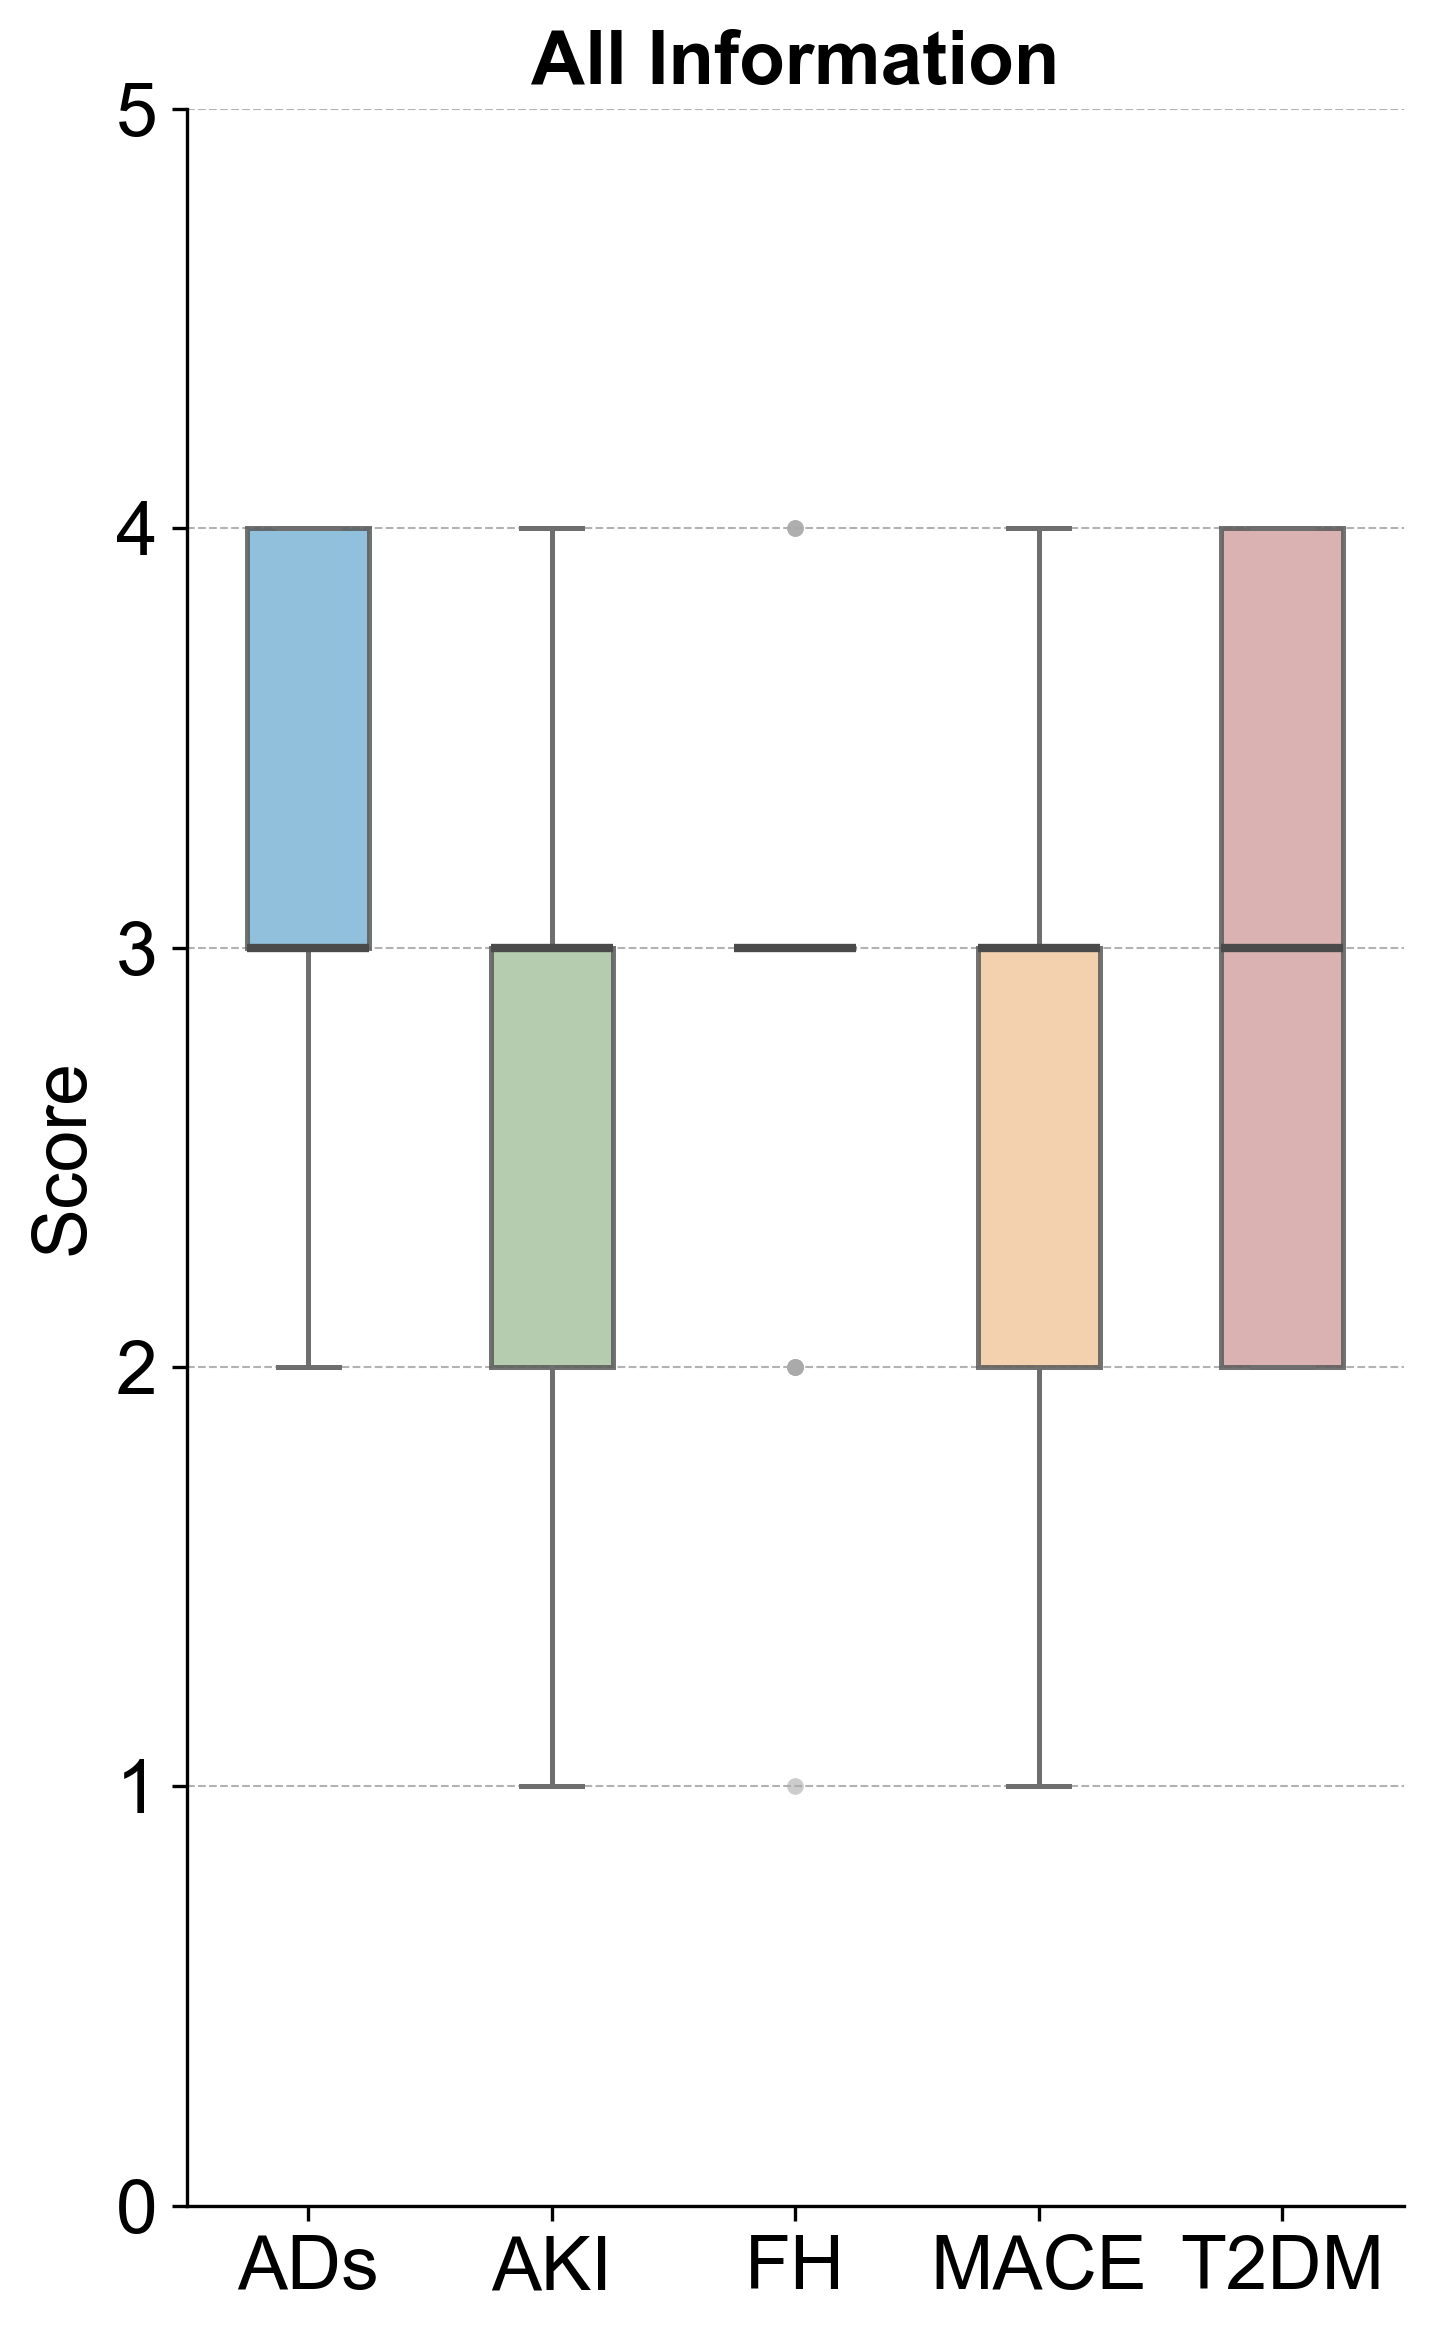

Saved: fig_comparison/boxplot_ALL.png


In [7]:
# Box plot: "All Information" — score distribution per disease
monet_colors = {
    'ADs':  '#7EB5D6',  # soft cerulean blue
    'AKI':  '#A8C5A0',  # sage green
    'FH':   '#C9B7D5',  # lavender
    'MACE': '#F2C9A0',  # warm peach
    'T2DM': '#D4A5A5',  # dusty rose
}

box_data = []
for disease in disease_list:
    scores = []
    for folder in ['LLM1', 'LLM2']:
        for r in reviewers:
            df = pd.read_csv(f'{folder}/{disease}_{r} copy.csv').set_index('Setting')
            scores.extend(df.loc['ALL'].tolist())
    box_data.append(scores)

fig, ax = plt.subplots(figsize=(5, 8))

bp = ax.boxplot(
    box_data,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='#4a4a4a', linewidth=2),
    whiskerprops=dict(linewidth=1.2, color='#6e6e6e'),
    capprops=dict(linewidth=1.2, color='#6e6e6e'),
    flierprops=dict(marker='o', markersize=4, markerfacecolor='#aaaaaa',
                    markeredgecolor='none', alpha=0.6),
)

for patch, disease in zip(bp['boxes'], disease_list):
    patch.set_facecolor(monet_colors[disease])
    patch.set_alpha(0.85)
    patch.set_edgecolor('#5a5a5a')
    patch.set_linewidth(1.2)

ax.set_xticks(range(1, len(disease_list) + 1))
ax.set_xticklabels(disease_list, fontsize=18)
ax.set_ylabel('Score', fontsize=18)
ax.set_xticklabels(disease_list, fontsize=18)
ax.set_title('All Information', fontsize=18, fontweight='bold')
ax.set_ylim(0, 5)
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.tick_params(axis='y', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6, color='grey')

plt.tight_layout()
plt.savefig('fig_comparison/boxplot_ALL.png', dpi=300, bbox_inches='tight', format='png')
plt.show()
print('Saved: fig_comparison/boxplot_ALL.png')

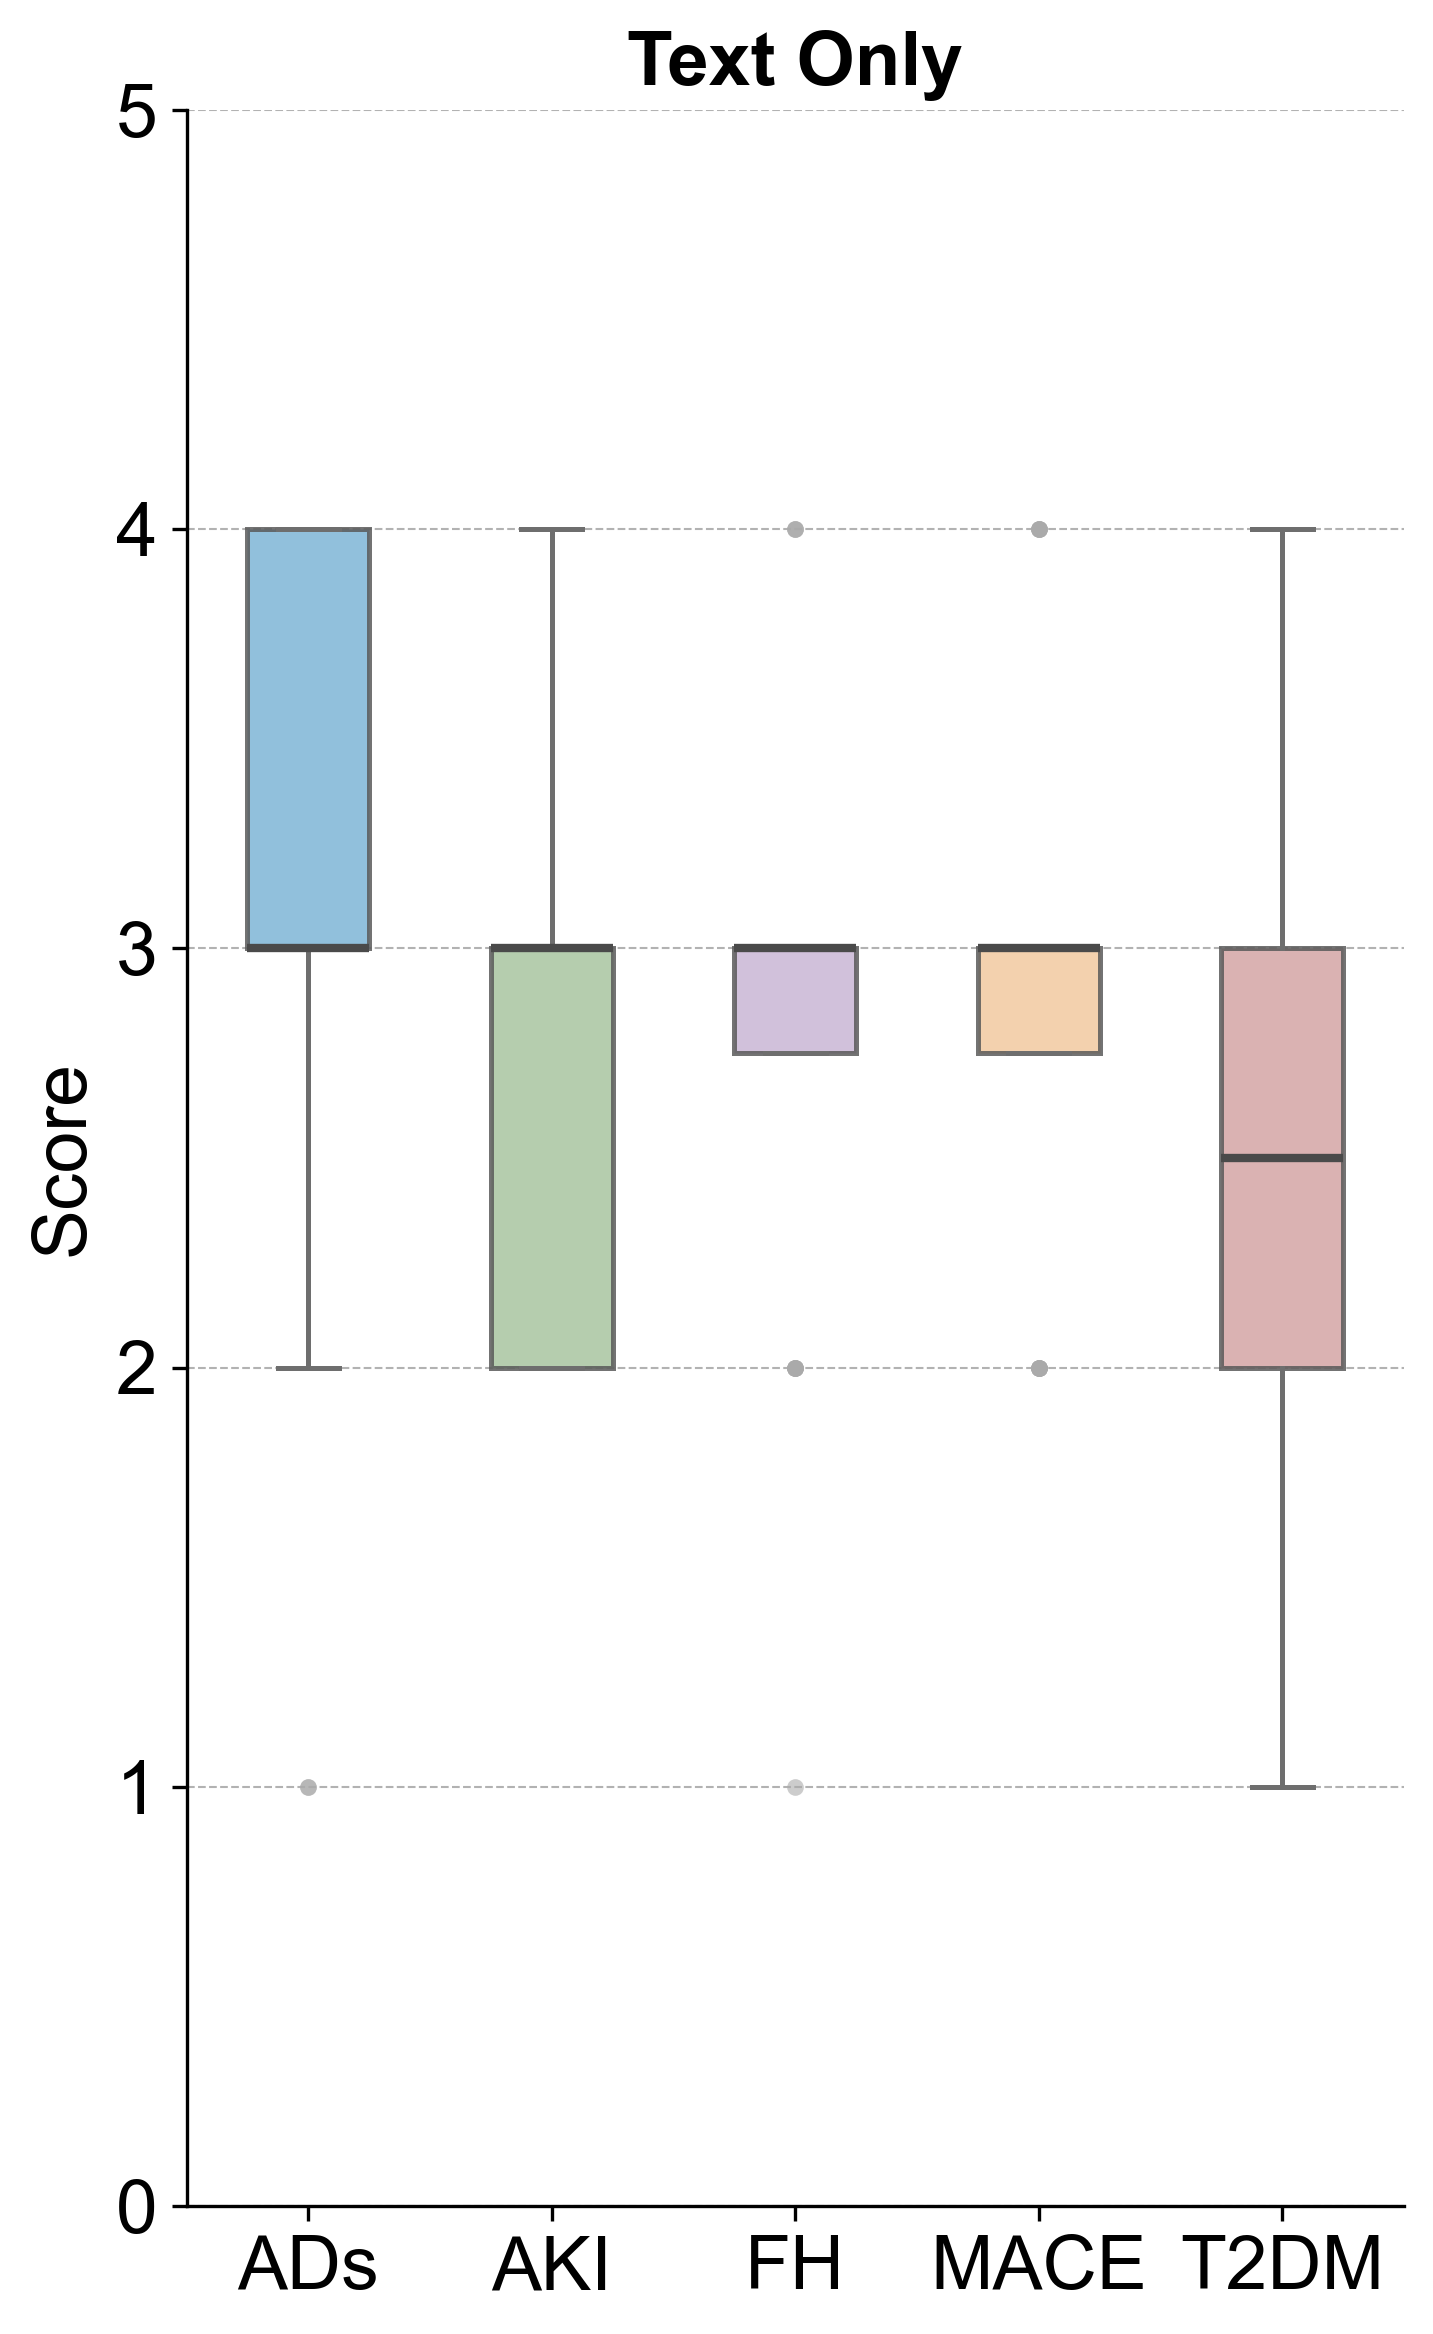

Saved: fig_comparison/boxplot_TEXT.png


In [8]:
# Box plot: "Text Only" — score distribution per disease
box_data_text = []
for disease in disease_list:
    scores = []
    for folder in ['LLM1', 'LLM2']:
        for r in reviewers:
            df = pd.read_csv(f'{folder}/{disease}_{r} copy.csv').set_index('Setting')
            scores.extend(df.loc['TEXT'].tolist())
    box_data_text.append(scores)

fig, ax = plt.subplots(figsize=(5, 8))

bp = ax.boxplot(
    box_data_text,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='#4a4a4a', linewidth=2),
    whiskerprops=dict(linewidth=1.2, color='#6e6e6e'),
    capprops=dict(linewidth=1.2, color='#6e6e6e'),
    flierprops=dict(marker='o', markersize=4, markerfacecolor='#aaaaaa',
                    markeredgecolor='none', alpha=0.6),
)

for patch, disease in zip(bp['boxes'], disease_list):
    patch.set_facecolor(monet_colors[disease])
    patch.set_alpha(0.85)
    patch.set_edgecolor('#5a5a5a')
    patch.set_linewidth(1.2)

ax.set_xticks(range(1, len(disease_list) + 1))
ax.set_xticklabels(disease_list, fontsize=18)
ax.set_ylabel('Score', fontsize=18)
ax.set_title('Text Only', fontsize=18, fontweight='bold')
ax.set_ylim(0, 5)
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.tick_params(axis='y', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6, color='grey')

plt.tight_layout()
plt.savefig('fig_comparison/boxplot_TEXT.png', dpi=300, bbox_inches='tight', format='png')
plt.show()
print('Saved: fig_comparison/boxplot_TEXT.png')

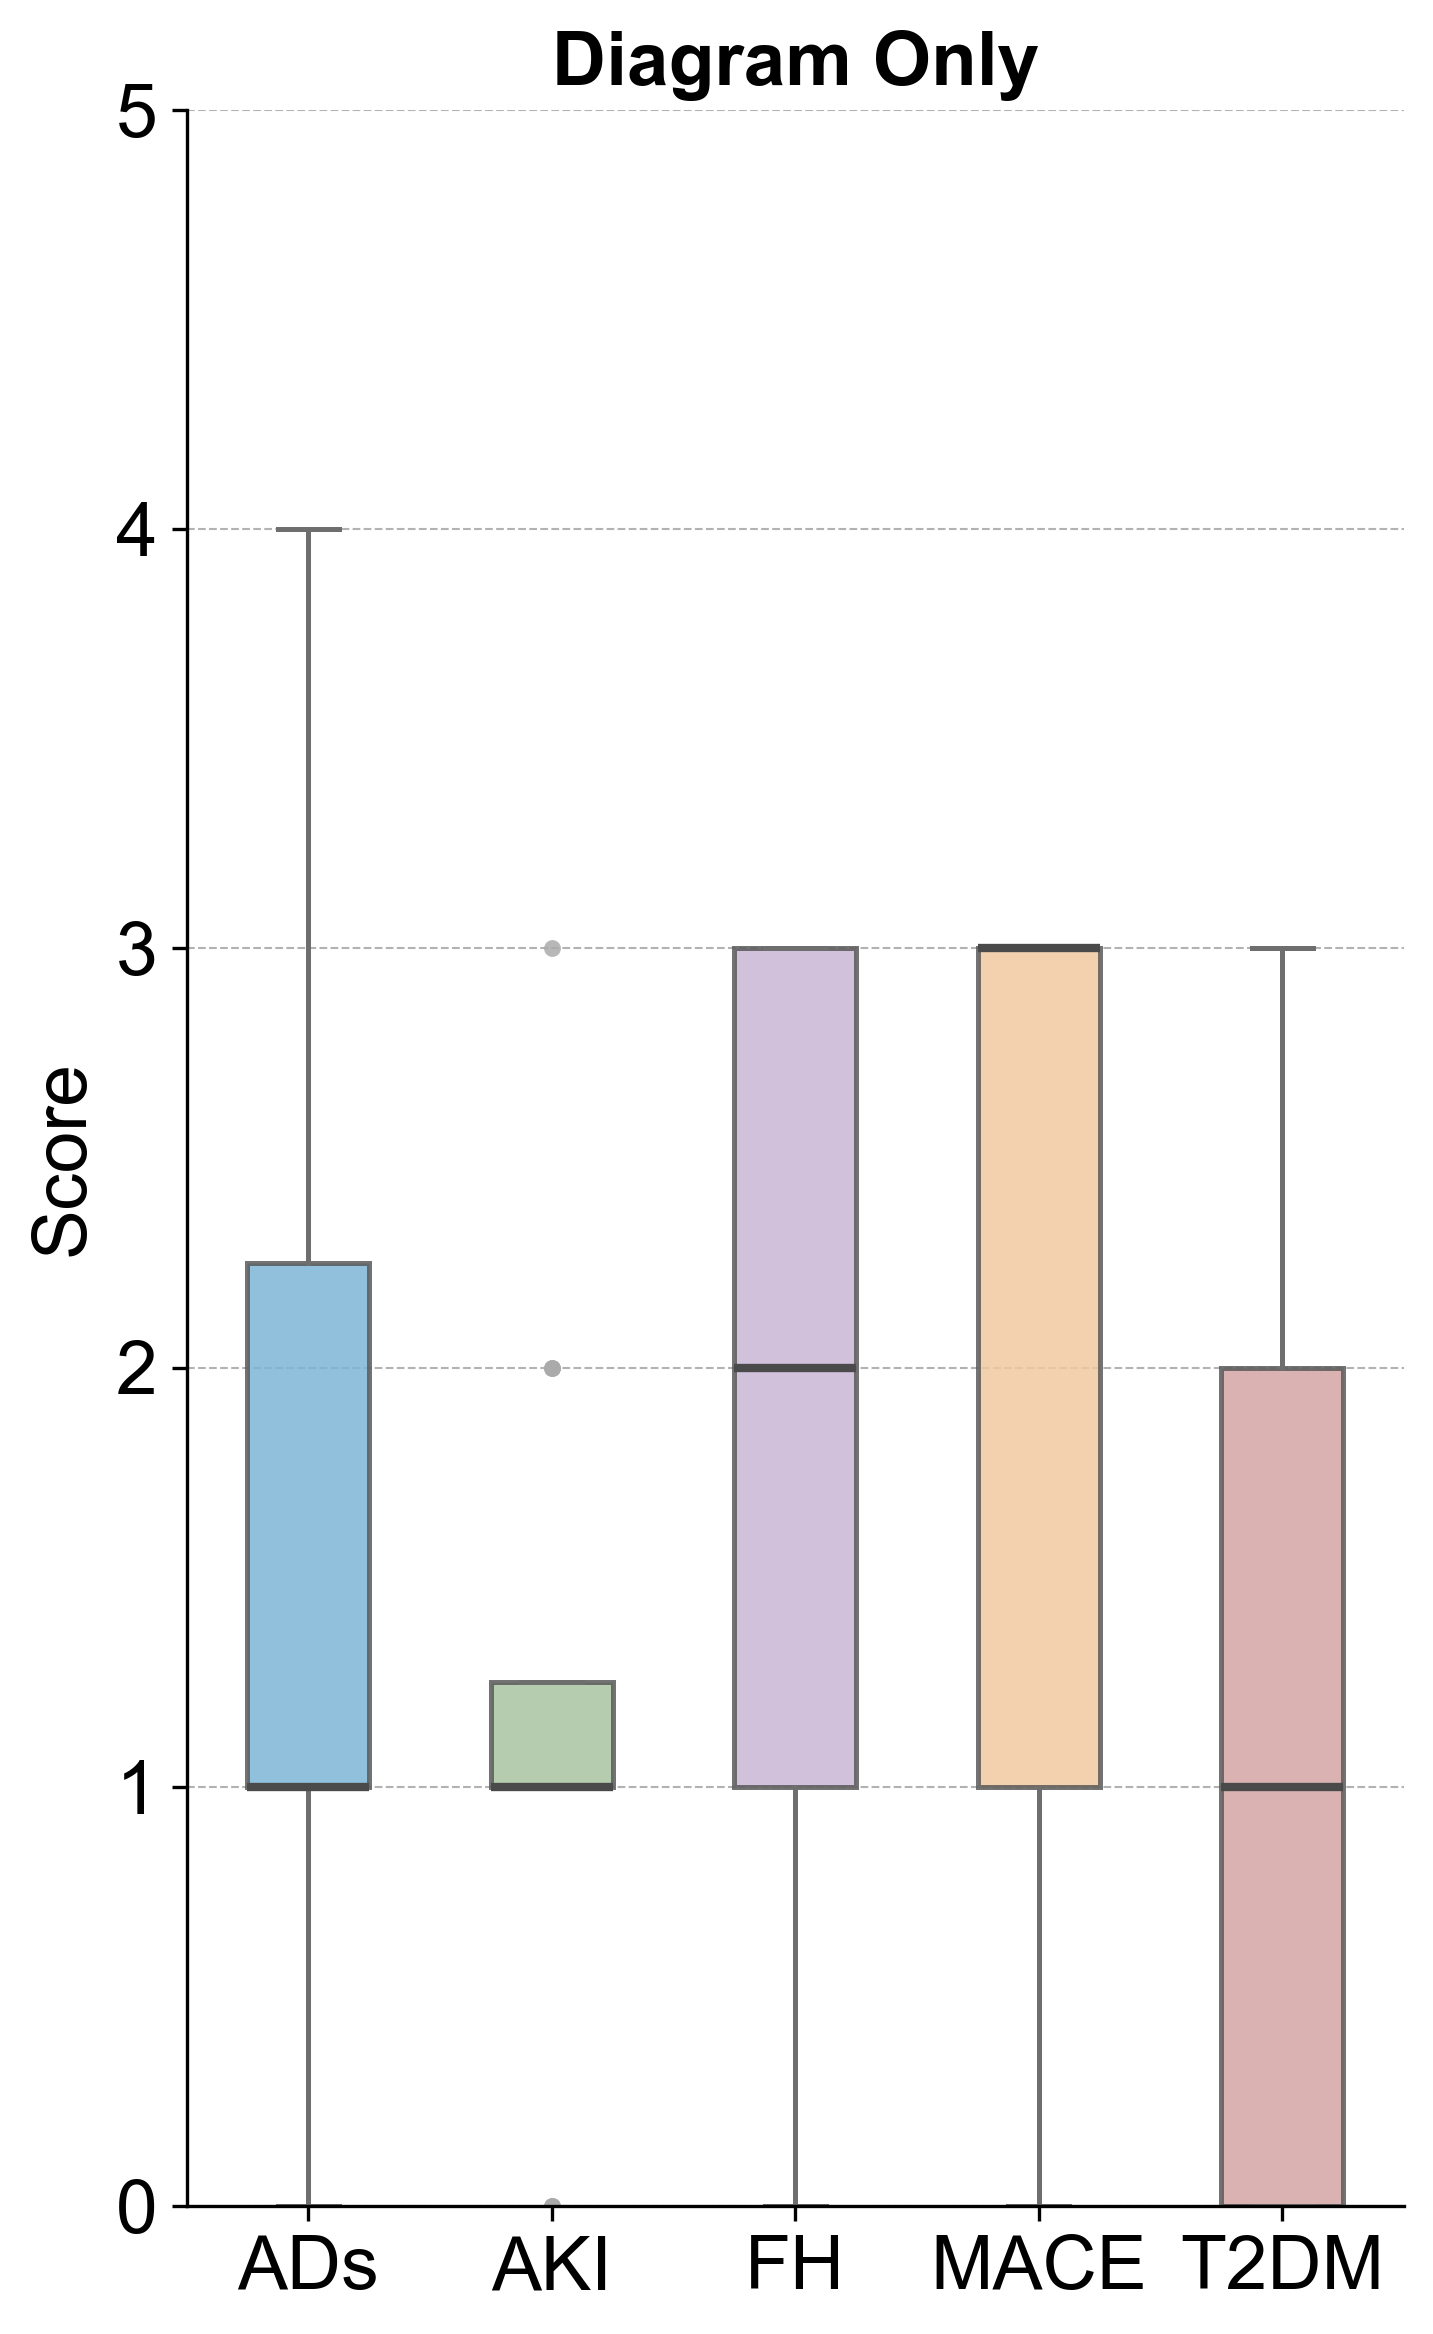

Saved: fig_comparison/boxplot_DIAG.png


In [9]:
# Box plot: "Diagram Only" — score distribution per disease
box_data_diag = []
for disease in disease_list:
    scores = []
    for folder in ['LLM1', 'LLM2']:
        for r in reviewers:
            df = pd.read_csv(f'{folder}/{disease}_{r} copy.csv').set_index('Setting')
            scores.extend(df.loc['DIAG'].tolist())
    box_data_diag.append(scores)

fig, ax = plt.subplots(figsize=(5, 8))

bp = ax.boxplot(
    box_data_diag,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='#4a4a4a', linewidth=2),
    whiskerprops=dict(linewidth=1.2, color='#6e6e6e'),
    capprops=dict(linewidth=1.2, color='#6e6e6e'),
    flierprops=dict(marker='o', markersize=4, markerfacecolor='#aaaaaa',
                    markeredgecolor='none', alpha=0.6),
)

for patch, disease in zip(bp['boxes'], disease_list):
    patch.set_facecolor(monet_colors[disease])
    patch.set_alpha(0.85)
    patch.set_edgecolor('#5a5a5a')
    patch.set_linewidth(1.2)

ax.set_xticks(range(1, len(disease_list) + 1))
ax.set_xticklabels(disease_list, fontsize=18)
ax.set_ylabel('Score', fontsize=18)
ax.set_title('Diagram Only', fontsize=18, fontweight='bold')
ax.set_ylim(0, 5)
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.tick_params(axis='y', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6, color='grey')

plt.tight_layout()
plt.savefig('fig_comparison/boxplot_DIAG.png', dpi=300, bbox_inches='tight', format='png')
plt.show()
print('Saved: fig_comparison/boxplot_DIAG.png')

In [10]:
box_data_diag[-2]

[3,
 3,
 3,
 2,
 3,
 3,
 1,
 2,
 2,
 3,
 3,
 3,
 3,
 1,
 1,
 2,
 1,
 3,
 3,
 3,
 1,
 1,
 2,
 0,
 3,
 3,
 3,
 1]